# Paso 2: Analisis (estadisticas y graficas)

**Orden:** Ejecutar despues del **Paso 1** (Notebook 01). **Todos los resultados y graficas de este notebook usan los mismos datos que el Paso 1:** si OVO_HOME esta definido se cargan desde el **backend OVO** (db.Design + descriptor_logic.get_wide_descriptor_table); si no, desde los **CSVs** que el Notebook 01 exporta a RESULTS_DIR (ovo_examples_all.csv.gz, ovo_publication_examples_1_jobs.csv). Asi se replican los resultados del paper completamente.

## Contexto cientifico (paper OVO, paper_extracted.txt)

Este notebook replica las **Figuras 2c y 3** del paper OVO (Prihoda et al., 2025). Usa las metricas del paper: PAE < 5, pLDDT > 80, Design RMSD < 2, Native Motif RMSD < 1.5-2 (scaffold); iPAE < 10, Binder RMSD < 2, ddG < -30 (binder). Analiza tres tipos de experimentos:

1. **Scaffold design (Figura 2c):** Backbones que conservan motivo funcional (1A4I oxidoreductasa, 5IUS PD-1). Metricas AF2 PAE, Design RMSD, Native Motif RMSD.

2. **Binder design (Figura 3):** Mini-proteinas binder al receptor de insulina (4ZXB/6PXV). Metricas AF2 iPAE, Target-aligned Binder RMSD, Binder pLDDT, Rosetta ddG.

3. **Diversificacion:** Variantes con RFdiffusion parcial (pool qki).

## Datos de entrada (Paso 1)

Misma fuente que el Notebook 01: **backend OVO** (librerias ovo.db, descriptor_logic, design_logic) o **CSVs** en RESULTS_DIR.

## Paso 2.1: Importar librerias

- **matplotlib/seaborn**: Librerias de visualizacion para generar scatter plots y histogramas
- **pandas**: Manipulacion de datos tabulares
- Se configura formato 'retina' para graficas de alta resolucion

In [1]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

def _find_ovo_home():
    cwd = os.getcwd()
    for base in [cwd, os.path.join(cwd, "..", ".."), os.path.join(cwd, "..", "..", "..")]:
        for rel in ["ovo_home", os.path.join("..", "ovo_home"), os.path.join("..", "..", "ovo_home")]:
            p = os.path.abspath(os.path.join(base, rel))
            if os.path.exists(p) and os.path.exists(os.path.join(p, "config.yml")):
                return p
    return None

OVO_HOME = os.environ.get("OVO_HOME") or _find_ovo_home()
if OVO_HOME:
    os.environ["OVO_HOME"] = OVO_HOME
LOAD_FROM_OVO = bool(OVO_HOME)

# Directorio de CSVs (mismo que RESULTS_DIR del Notebook 01). En Colab: OVO_RESULTS_DIR.
_candidates = [
    os.path.join(os.getcwd(), "..", "..", "jupyter_notebooks_example", "data", "results"),
    os.path.join(os.getcwd(), "jupyter_notebooks_example", "data", "results"),
]
RESULTS_DIR = os.environ.get("OVO_RESULTS_DIR") or next(
    (os.path.abspath(p) for p in _candidates if os.path.isdir(os.path.abspath(p))),
    os.path.abspath(_candidates[0]),
)
print("RESULTS_DIR (CSVs):", RESULTS_DIR)
if LOAD_FROM_OVO:
    print("Carga desde backend OVO: activada (OVO_HOME =", OVO_HOME, ")")

RESULTS_DIR (CSVs): d:\ProyectosUniversidad\BioInformatica\jupyter_notebooks_example\data\results
Carga desde backend OVO: activada (OVO_HOME = d:\ProyectosUniversidad\BioInformatica\ovo_home )


## Paso 2.2: Cargar la tabla completa de diseños

Si **OVO_HOME** está definido, los datos se cargan desde el **backend OVO** (BD + `descriptor_logic.get_wide_descriptor_table`). En caso contrario se usa el CSV exportado por el Notebook 01. Cada fila es un diseño con pool_id, secuencia, estructura predicha y métricas (AF2 PAE, pLDDT, RMSD, Rosetta ddG, etc.).

In [2]:
if LOAD_FROM_OVO:
    from ovo import db
    from ovo.core.logic import descriptor_logic, design_logic, project_logic
    project = project_logic.get_or_create_project("OVO Publication Examples 1")
    round_ids = db.Round.select_values("id", project_id=project.id)
    pool_ids = list(db.Pool.select_values("id", round_id__in=round_ids))
    designs = db.Design.select_dataframe(pool_id__in=pool_ids)
    desc_table = descriptor_logic.get_wide_descriptor_table(pool_ids=pool_ids)
    designs = designs.join(desc_table)
    print("Cargado desde BD OVO:", len(designs), "disenos,", len(pool_ids), "pools")
else:
    designs = pd.read_csv(os.path.join(RESULTS_DIR, 'ovo_examples_all.csv.gz'), index_col=0)
    print("Cargado desde CSV (Paso 1):", len(designs), "disenos, desde", RESULTS_DIR)
# Verificacion: mismos datos que exporta el Notebook 01 (paper/tesis)
key_cols = ['AF2 PAE', 'AF2 Design RMSD', 'AF2 Native Motif RMSD', 'AF2 iPAE', 'AF2 Target-aligned Binder RMSD', 'Rosetta ddG', 'accepted', 'pool_id']
missing = [c for c in key_cols if c not in designs.columns]
if missing:
    print("AVISO: faltan columnas para el paper:", missing)
else:
    n_acc = int(designs['accepted'].sum()) if 'accepted' in designs.columns else 0
    print("Datos Paso 1 OK. Total:", len(designs), "| Aceptados:", n_acc, "(tesis: 361 en pools paper)")
    print(designs.groupby('pool_id')['accepted'].sum().to_frame('aceptados'))
designs.head()

╭───────────────────────────────────────────── Platform Warning ──────────────────────────────────────────────╮
│ ⚠️  WARNING: Windows Detected ⚠️                                                                            │
│                                                                                                             │
│ OVO workflows use Nextflow which is not supported on Windows.                                               │
│ Please use Linux or macOS, or run OVO in WSL2 (Windows Subsystem for Linux) to enable submitting workflows. │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

OVO home d:\ProyectosUniversidad\BioInformatica\ovo_home

Cargado desde BD OVO: 898 disenos, 10 pools
Datos Paso 1 OK. Total: 898 | Aceptados: 898 (tesis: 361 en pools paper)
         aceptados
pool_id           
avz              5
bbc              3
efm            537
mmo              1
ogc             26
qki             37
rsj             13
xeh            275
zuk              1


D:\ProyectosUniversidad\BioInformatica\ovo\ovo\core\logic\descriptor_logic.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0, seq_column, pd.Series(sequences_by_design_id))
D:\ProyectosUniversidad\BioInformatica\ovo\ovo\core\logic\descriptor_logic.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0, seq_column, pd.Series(sequences_by_design_id))
D:\ProyectosUniversidad\BioInformatica\ovo\ovo\core\logic\descriptor_logic.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,...,0.008814,2397.582566,0.517766,2397.582566,0.517766,-53204.939693,247.264672,-37802.189478,524.728685,-53729.668377
ovo_avz_0124_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,...,0.002133,1329.886461,0.221943,494.351643,0.082502,-29282.013327,1603.259674,-20382.537688,5073.431641,-34355.444969
ovo_avz_0299_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MSIEEIKKILEEIKKEAEAKNAKKVAEAAAKDPELAKKLAAELTAE...,...,0.013346,1431.141721,0.264025,1222.315483,0.225499,-31439.230457,1221.440562,-21455.968271,3326.778095,-34766.008552
ovo_avz_0481_cycle03,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MEAALKAAEEEKEFQKQVELAKLMIESYKKEGDEEQAEYWEKILEE...,...,0.004164,2322.248872,0.491070,2295.299667,0.485372,-62153.827602,169.365019,-47174.741642,462.410420,-62616.238021
ovo_avz_0732_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKEKKLKELEKQAKEVEEEGRKKVKEAEAKLKAGDKSEEVKEL...,...,0.026966,1342.739388,0.243623,1156.812464,0.209889,-18930.954449,6064.660410,-19659.415027,11991.801964,-30922.756413


## Paso 2.3: Cargar y ordenar la tabla de jobs

La tabla de jobs tiene multi-nivel en las columnas (Pool, Job, Designs, Workflow, RFdiffusion, ProteinMPNN, etc.). Contiene los parametros de cada experimento: que contigs se usaron, cuantos backbones se generaron, cuantas secuencias por backbone, los umbrales de filtrado, etc.

In [3]:
if LOAD_FROM_OVO:
    jobs = design_logic.get_design_jobs_table(project.id)
    print("Jobs desde backend OVO (Paso 1)")
    jobs = jobs.sort_values(by=('Pool', 'name'))
else:
    jobs = pd.read_csv(os.path.join(RESULTS_DIR, 'ovo_publication_examples_1_jobs.csv'), index_col=0, header=[0, 1])
    print("Jobs desde CSV del Paso 1:", RESULTS_DIR)
    jobs = jobs.sort_values(by=('Pool', 'name'))
jobs.head()

Jobs desde backend OVO (Paso 1)


Pool  \
                                                    name   
(Pool, id)                                                 
ogc             1A41 6*100*8 designs active site weights   
jov                 1A41 6*100*8 designs default weights   
mmo                         4ZXB 1000 designs beta sheet   
avz                    4ZXB 1000 designs default weights   
bbc         4ZXB 1000 designs default weights ligandmpnn   

                                                                 Job  \
                                                  description status   
(Pool, id)                                                             
ogc         length 150 with 10-100 residues spacing the ac...   Done   
jov         length 150 with 10-100 residues spacing the ac...   Done   
mmo         Insulin receptor miniprotein binders hotspot E...   Done   
avz         Insulin receptor miniprotein binders hotspot E...   Done   
bbc         Insulin receptor miniprotein binders hotspot E...   Done   

                                        Designs       Workflow  \
                duration       created accepted total    input   
(Pool, id)                                                       
ogc         119d:21h:13m  4 months ago       26    26      NaN   
jov         119d:20h:01m  4 months ago        0     0      NaN   
mmo         119d:21h:10m  4 months ago        1     1      NaN   
avz         119d:21h:10m  4 months ago        5     5      NaN   
bbc         108d:21h:02m  4 months ago        3     3      NaN   

                                         \
                                   type   
(Pool, id)                                
ogc         RFdiffusion scaffold design   
jov         RFdiffusion scaffold design   
mmo           RFdiffusion binder design   
avz           RFdiffusion binder design   
bbc           RFdiffusion binder design   

                                                  RFdiffusion  ...  \
                                                      contigs  ...   
(Pool, id)                                                     ...   
ogc         [10-100/A56-56/10-100/A100-100/10-100/A125-125...  ...   
jov         [10-100/A56-56/10-100/A100-100/10-100/A125-125...  ...   
mmo                                         [E6-155/0 50-100]  ...   
avz                                         [E6-155/0 50-100]  ...   
bbc                                         [E6-155/0 50-100]  ...   

                         BindCraft                               \
           number_of_final_designs time_limit_hours filter_type   
(Pool, id)                                                        
ogc                            NaN              NaN         NaN   
jov                            NaN              NaN         NaN   
mmo                            NaN              NaN         NaN   
avz                            NaN              NaN         NaN   
bbc                            NaN              NaN         NaN   

                                                                 \
           design_protocol interface_protocol template_protocol   
(Pool, id)                                                        
ogc                    NaN                NaN               NaN   
jov                    NaN                NaN               NaN   
mmo                    NaN                NaN               NaN   
avz                    NaN                NaN               NaN   
bbc                    NaN                NaN               NaN   

                                                         \
           prediction_protocol custom_advanced_settings   
(Pool, id)                                                
ogc                        NaN                      NaN   
jov                        NaN                      NaN   
mmo                        NaN                      NaN   
avz                        NaN                      NaN   
bbc                        NaN                      NaN   

            

---
## SECCION A: Scaffold Design - Oxidoreductasa (PDB 1A4I)

### Que es scaffold design

El **scaffold design** consiste en generar un **nuevo backbone de proteina** (la columna vertebral 3D) que sostenga un **motivo funcional** existente (un sitio activo de una enzima, una interfaz de union, etc.). Es como diseñar un nuevo edificio alrededor de una habitacion especifica que debe conservarse exactamente igual.

### El experimento: Oxidoreductasa 1A4I

Se tomaron los **residuos 56, 100 y 125** del sitio activo de la oxidoreductasa (PDB: 1A4I) y se usaron como motivo fijo. RFdiffusion genero nuevos backbones de ~150 aminoacidos que conectan esos tres residuos con entre 10-100 residuos nuevos, en 6 permutaciones del orden de los residuos fijos.

### Paso 4: Filtrar los scaffold jobs

In [4]:
scaffold_jobs = jobs[jobs[('Workflow','type')] == 'RFdiffusion scaffold design']

### Paso 5: Parametros de los scaffold jobs

Muestra los parametros clave de cada scaffold job:
- **contigs**: Define la topologia del scaffold. Ej: `10-100/A56-56/10-100/A100-100/10-100/A125-125/10-100` significa "genera 10-100 residuos, luego fija el residuo 56, luego 10-100 residuos, fija el 100, etc."
- **num_designs**: Cuantos backbones genero RFdiffusion (100 por cada permutacion de contigs, x6 = 600)
- **num_sequences**: Cuantas secuencias genero ProteinMPNN por backbone (8 para ogc, 2 para jov)

Los pools `ogc` (active site weights) y `jov` (default weights) usan los mismos contigs pero diferentes pesos de RFdiffusion para comparar.

In [5]:
scaffold_jobs[[
    ('Pool','name'), ('RFdiffusion', 'contigs'), ('RFdiffusion', 'num_designs'), 
    ('ProteinMPNN', 'num_sequences'), 
]]

Pool  \
                                                     name   
(Pool, id)                                                  
ogc              1A41 6*100*8 designs active site weights   
jov                  1A41 6*100*8 designs default weights   
zuk                      5IUS 500*5 designs PD1 interface   
xeh         5IUS 500*5 designs PD1 interface with inpaint   

                                                  RFdiffusion              \
                                                      contigs num_designs   
(Pool, id)                                                                  
ogc         [10-100/A56-56/10-100/A100-100/10-100/A125-125...       100.0   
jov         [10-100/A56-56/10-100/A100-100/10-100/A125-125...       100.0   
zuk         [0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53-...      1000.0   
xeh         [0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53-...      1000.0   

             ProteinMPNN  
           num_sequences  
(Pool, id)                
ogc                  8.0  
jov                  2.0  
zuk                  5.0  
xeh                  5.0

### Paso 6: Umbrales de filtrado y resultados

Muestra cuantos diseños fueron aceptados y los umbrales de filtrado aplicados. Para oxidoreductasa los umbrales son:
- **PAE < 5 A** (Angstroms): Error de alineamiento predicho bajo = alta confianza global de la estructura
- **pLDDT > 80**: Alta confianza local por residuo (escala 0-100)
- **Design RMSD < 2 A**: La secuencia diseñada se pliega en el backbone generado por RFdiffusion
- **Native Motif RMSD < 1.5 A**: El sitio activo se conserva respecto a la estructura original

**Resultado clave del paper:** Con pesos de RFdiffusion para sitio activo (pool `ogc`), se aceptaron diseños de entre 4800 generados. Con pesos default (pool `jov`), **ningun diseño fue aceptado**, demostrando que los pesos especializados (*active site weights*) son cruciales para conservar la geometria del sitio activo durante el scaffold design. Los numeros exactos de aceptados se muestran en la tabla de abajo.

In [6]:
scaffold_jobs[['Pool','Designs', 'Thresholds']].dropna(how='all', axis=1)

Pool  \
                                                     name   
(Pool, id)                                                  
ogc              1A41 6*100*8 designs active site weights   
jov                  1A41 6*100*8 designs default weights   
zuk                      5IUS 500*5 designs PD1 interface   
xeh         5IUS 500*5 designs PD1 interface with inpaint   

                                                               Designs        \
                                                  description accepted total   
(Pool, id)                                                                     
ogc         length 150 with 10-100 residues spacing the ac...       26    26   
jov         length 150 with 10-100 residues spacing the ac...        0     0   
zuk                       PD1 interface, no sequence redesign        1     1   
xeh                                PD1 interface, inpaint seq      275   275   

                Thresholds                                           
           AF2 Design RMSD AF2 Native Motif RMSD  AF2 PAE AF2 pLDDT  
(Pool, id)                                                           
ogc                ≤ 2.000               ≤ 1.500  ≤ 5.000  ≥ 80.000  
jov                ≤ 2.000               ≤ 1.500  ≤ 5.000  ≥ 80.000  
zuk                ≤ 2.000               ≤ 2.000  ≤ 5.000  ≥ 80.000  
xeh                ≤ 2.000               ≤ 2.000  ≤ 5.000  ≥ 80.000

---
## SECCION B: Scaffold Design - Interfaz PD-1/PD-L1 (PDB 5IUS)

### El experimento: Interfaz PD-1

PD-1 (Programmed Death-1) es un receptor inmunologico clave en inmunoterapia contra el cancer. Se tomo la estructura de la interfaz PD-1/PD-L1 (PDB: 5IUS) y se usaron los **segmentos 63-82 y 119-140** de la cadena A (los que hacen contacto con PD-L1) como motivo fijo.

RFdiffusion genero nuevos scaffolds que conectan estos dos segmentos con 15-40 residuos nuevos entre ellos y 0-30 en los extremos. En una variante (pool `xeh`), los residuos que miran hacia el interior del scaffold se enmascararon con **sequence inpainting** (se ocultan a RFdiffusion) y se rediseñaron con ProteinMPNN para mejor empaquetamiento.

### Paso 7: Filtrar diseños de interfaz PD-1

Selecciona los diseños de los pools `zuk` (sin inpainting) y `xeh` (con inpainting) para compararlos.

### Resumen del experimento de oxidoreductasa (segun el paper)

Para el scaffold design del motivo de la oxidoreductasa, se usaron los **residuos 56, 100 y 125** de la cadena A del PDB 1A4I como motivo fijo de entrada. Se generaron entre 10 y 100 residuos nuevos entre cada par de residuos fijos y en los extremos N/C-terminales, con una restriccion de longitud total de exactamente **150 aminoacidos**.

En total se generaron: **100 backbones x 6 permutaciones** del orden de los tres residuos fijos **x 8 diseños de secuencia** = **4800 secuencias diseñadas**, que se filtraron con AlphaFold2 usando los umbrales: PAE < 5 A, pLDDT > 80, Design RMSD < 2 A y Native Motif RMSD < 1.5 A.

**Resultado:** Se obtuvieron **13 diseños aceptados** cuando se emplearon los pesos de RFdiffusion para sitio activo (*active site weights*). Ejecutar el mismo workflow con pesos por defecto de RFdiffusion **no produjo ningun diseño aceptado** debido a un Native Motif RMSD mas alto (el sitio activo no se conservaba correctamente).



### Paso 8: Scatter plot AF2 PAE vs. AF2 Design RMSD (Figura 2c del paper)

**Esta es la grafica clave de la Figura 2c del paper.** Cada punto es un diseño de proteina:
- **Eje X (AF2 PAE):** Confianza global de AlphaFold2. Mas bajo = mejor.
- **Eje Y (AF2 Design RMSD):** Que tan parecida es la estructura predicha por AF2 al backbone diseñado por RFdiffusion. Mas bajo = la secuencia se pliega como se esperaba.
- **Color:** Distingue los diseños con inpainting (xeh, naranja) vs. sin inpainting (zuk, azul)

Los diseños "buenos" estan en la **esquina inferior izquierda** (bajo PAE y bajo RMSD). La mayoria de los diseños con inpainting (`xeh`) tienen mejor RMSD porque el rediseño de los residuos interiores mejora el empaquetamiento.

In [7]:
interface_designs = designs[designs['pool_id'].isin(['zuk', 'xeh'])]
interface_designs.head()

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_xeh_0008_seq02,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,AALYESRDVRVGEINLSDKISIRESPRVHTETQAETDAAVAAAMAA...,...,0.026279,683.348839,0.111084,370.301777,0.060195,-10240.110952,6687.920601,-12414.339797,13125.230207,-23365.341159
ovo_xeh_0023_seq04,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,APAGDLRIGVIFLDDKIHIEESPRVPDDSPEARERLLAQGVAILQQ...,...,0.011018,1101.154542,0.184330,365.199421,0.061133,-19816.273257,2295.776046,-13715.433234,5402.875865,-25219.149122
ovo_xeh_0025_seq05,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,ADAVAQVTALLERAAREEGLESLDVRMGVISLSKKISIEESPRRRV...,...,0.004040,2075.170957,0.333473,1266.028591,0.203447,-39230.856128,1195.796487,-26765.925576,3002.076573,-42232.932701
ovo_xeh_0026_seq03,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,PVLGPREPSDFDIRAGLINLKDKISIEETPRVWADRGPRGHDAFAQ...,...,0.013014,980.792725,0.155169,295.232611,0.046708,-19787.057802,2511.788356,-14040.251232,6280.290531,-26067.348333
ovo_xeh_0029_seq03,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,PYFPEVDPESDVRFGVIHLDDKISIEESPRIKNSDVEKINAALAAM...,...,0.001755,1105.045041,0.239445,639.316527,0.138529,-24650.734607,502.436116,-14994.144542,1671.549197,-26322.283804


### Paso 9: Zoom en la zona de diseños de alta calidad

Acercamiento a la region de interes (PAE 2.8-6, RMSD 0.7-3) para ver mejor la distribucion de los diseños que pasan los umbrales de aceptacion. Los diseños aceptados estan tipicamente con PAE < 5 y Design RMSD < 2.

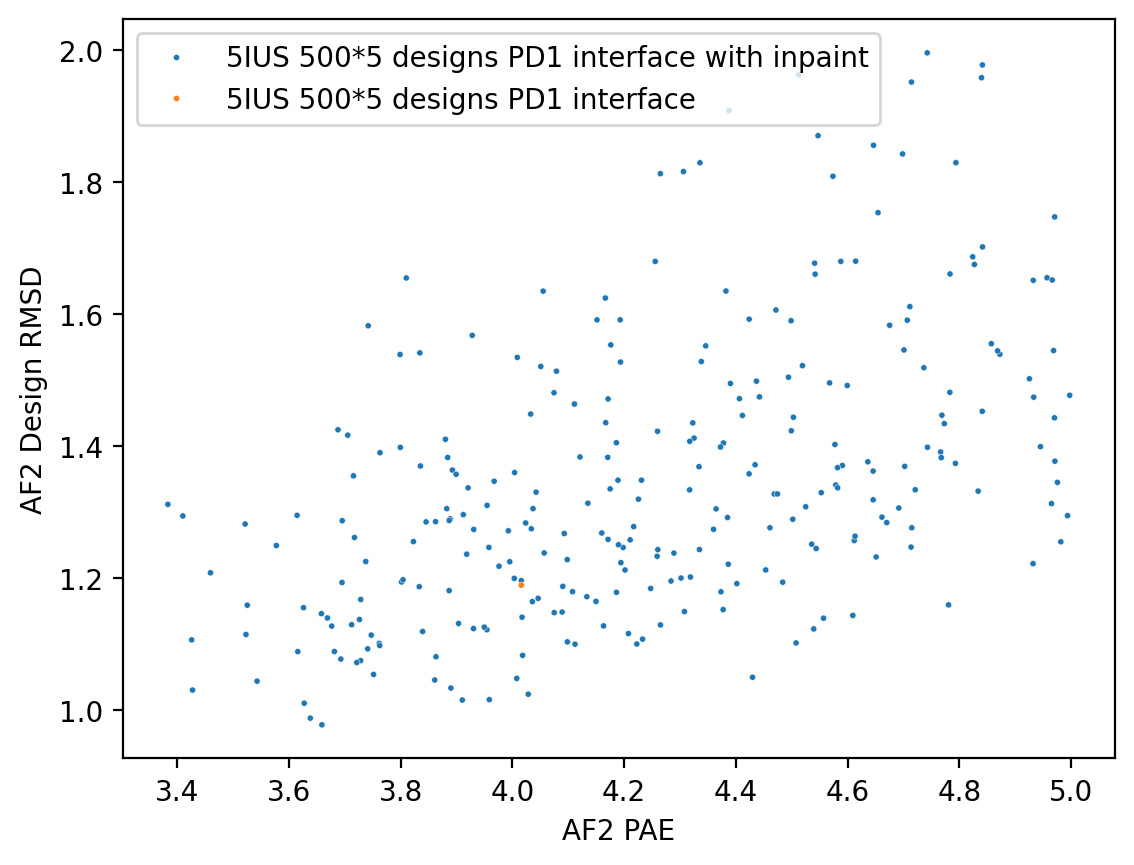

In [8]:
hue = jobs[('Pool','name')].loc[interface_designs.pool_id]
sns.scatterplot(interface_designs, x='AF2 PAE', y='AF2 Design RMSD', hue=hue.values, s=5);

### Paso 10: Scatter plot AF2 PAE vs. Native Motif RMSD

Similar al anterior pero el eje Y ahora es **Native Motif RMSD**: que tan bien se conserva el motivo funcional (los segmentos 63-82 y 119-140 de PD-1). Un valor bajo significa que la interfaz se mantiene en su posicion original.

**Resultado clave:** Con inpainting (xeh), **275 de 5000** diseños fueron aceptados (5.5%). Sin inpainting (zuk), **solo 1** fue aceptado, principalmente por alto Native Motif RMSD de los residuos interiores. Esto demuestra que el inpainting es esencial para el scaffold design de interfaces.

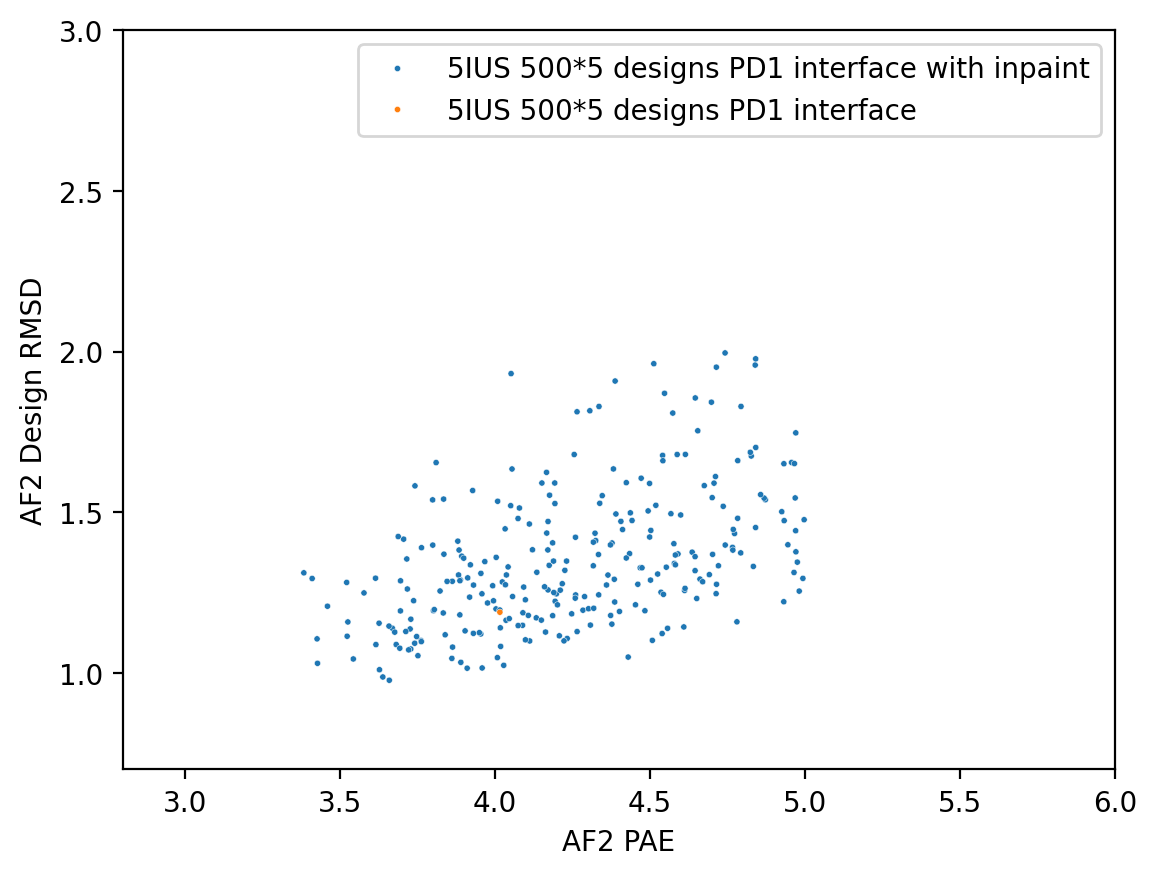

In [9]:
ax = sns.scatterplot(interface_designs, x='AF2 PAE', y='AF2 Design RMSD', hue=hue.values, s=5);
ax.set_xlim([2.8, 6]);
ax.set_ylim([0.7, 3]);

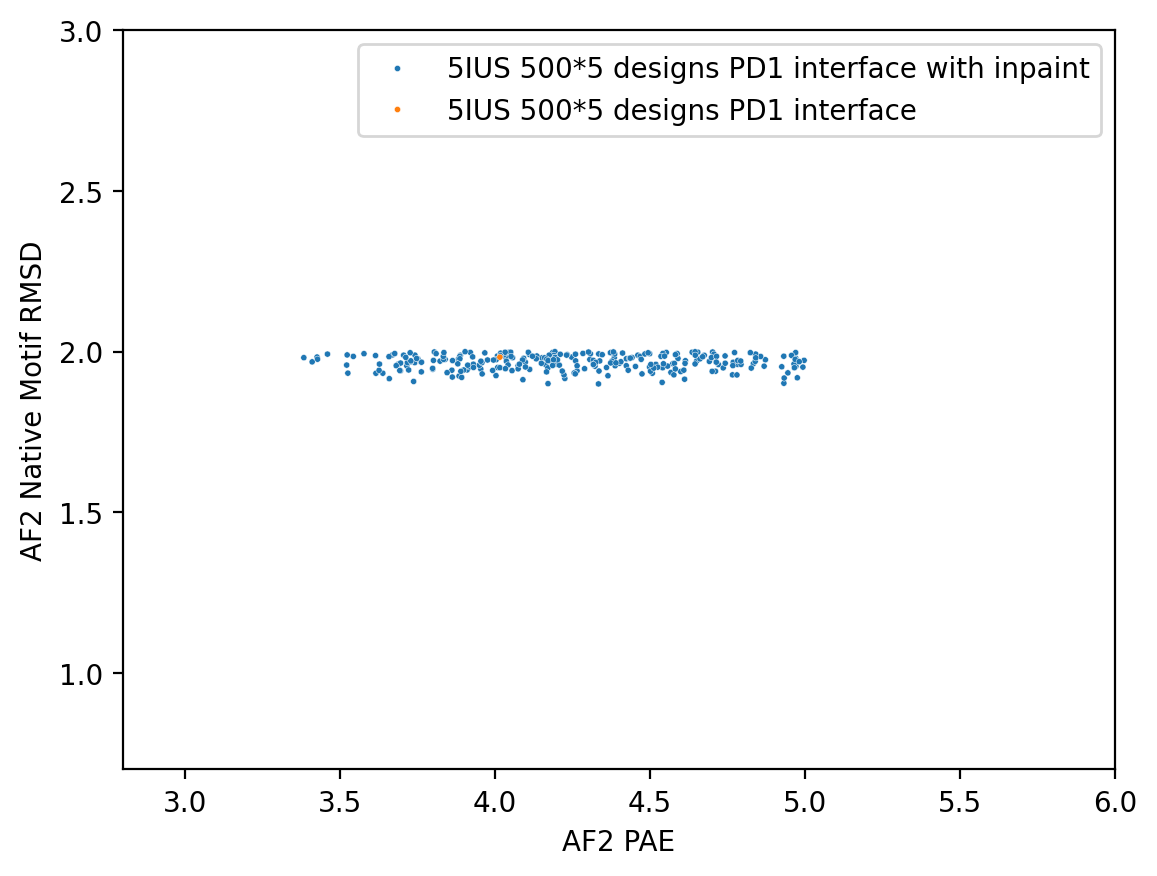

In [10]:
ax = sns.scatterplot(interface_designs, x='AF2 PAE', y='AF2 Native Motif RMSD', hue=hue.values, s=5);
ax.set_xlim([2.8, 6]);
ax.set_ylim([0.7, 3]);

### Resumen del experimento de interfaz PD-1 (segun el paper)

Para el scaffold design de la interfaz PD-1, se unieron los **segmentos 119-140 y 63-82** de la cadena A del PDB 5IUS con entre 15 y 40 residuos generados, mas 0 a 30 residuos adicionales en los extremos N/C-terminales. Los residuos orientados hacia el interior (opuestos a la interfaz) se enmascararon mediante **sequence inpainting** de RFdiffusion y se rediseñaron con ProteinMPNN para lograr un mejor empaquetamiento contra el scaffold diseñado.

En total se generaron: **1000 backbones x 5 diseños de secuencia** = **5000 secuencias diseñadas**, filtradas con AlphaFold2 (PAE < 5 A, pLDDT > 80, Design RMSD < 2 A y Native Motif RMSD < 2 A).

**Resultado:** Se obtuvieron **275 diseños aceptados** con inpainting (pool `xeh`). El mismo workflow **sin inpainting** (pool `zuk`) produjo **solo 1 diseño aceptado**, principalmente debido a un Native Motif RMSD mas alto en los residuos orientados hacia el interior, donde se espera que las cadenas laterales se reorienten. Un umbral menos estricto podria haber aceptado mas diseños sin inpainting.


---
## SECCION C: Binder Design con RFdiffusion - Receptor de Insulina (PDB 4ZXB)

### Que es binder design

El **binder design** consiste en diseñar una **proteina completamente nueva** (mini-proteina de 50-100 residuos) que se una especificamente a una superficie de un target. Es el paso mas ambicioso: no solo se genera un backbone nuevo, sino que se diseña una proteina funcional que se une a un target real.

### El experimento: Receptor de Insulina 4ZXB

Se diseñaron mini-proteinas binder contra la cadena E del receptor de insulina (residuos 6-155), con hotspots en los residuos **64, 88 y 96**. El pipeline fue:
1. **RFdiffusion**: Genera 1000 backbones de binders de 50-100 residuos
2. **ProteinMPNN + FastRelax**: Diseña secuencias con 3 ciclos de relajacion (4000 secuencias total)
3. **AlphaFold2 multimer**: Valida el complejo binder-target
4. **PyRosetta**: Calcula la energia de union (ddG)

### Paso 11: Filtrar los binder jobs (RFdiffusion)

Selecciona los pools `mmo` (beta sheet weights) y `avz` (default weights).

In [11]:
rf_binder_jobs = jobs.loc[['mmo','avz']]

### Paso 12: Parametros de los binder jobs

Muestra los parametros:
- **contigs**: `E6-155/0 50-100` = target es cadena E residuos 6-155, generar binder de 50-100 residuos
- **hotspots**: `E64,E88,E96` = residuos del target donde se quiere que el binder haga contacto
- **num_designs**: 1000 backbones por pool
- **fastrelax_cycles**: 3 ciclos de relajacion (genera 4 secuencias por backbone: 1 inicial + 3 ciclos)

In [12]:
rf_binder_jobs[[
    ('Pool','name'), ('RFdiffusion', 'contigs'), ('RFdiffusion', 'hotspots'), ('RFdiffusion', 'num_designs'), 
    ('ProteinMPNN', 'num_sequences'), ('ProteinMPNN', 'fastrelax_cycles')
]]

Pool        RFdiffusion               \
                                         name            contigs     hotspots   
(Pool, id)                                                                      
mmo              4ZXB 1000 designs beta sheet  [E6-155/0 50-100]  E64,E88,E96   
avz         4ZXB 1000 designs default weights  [E6-155/0 50-100]  E64,E88,E96   

                         ProteinMPNN                   
           num_designs num_sequences fastrelax_cycles  
(Pool, id)                                             
mmo             1000.0           1.0              3.0  
avz             1000.0           1.0              3.0

### Paso 13: Resultados y umbrales de binder design

Muestra los umbrales de filtrado para binders (diferentes a scaffold design):
- **iPAE < 10** (interface PAE): Confianza en la interfaz binder-target
- **pLDDT > 80**: Confianza local alta
- **Target-aligned Binder RMSD < 2 A**: El binder se coloca donde se esperaba
- **Rosetta ddG < -30 REU**: Energia de union fuerte (mas negativo = mejor)

**Resultado:** Pool `avz` (default weights): **5 de 4000** aceptados (0.125%). Pool `mmo` (beta sheet): **1 de 4000** aceptado con 20% de laminas beta.

In [13]:
rf_binder_jobs[['Pool', 'Designs', 'Thresholds']].dropna(how='all', axis=1)

Pool  \
                                         name   
(Pool, id)                                      
mmo              4ZXB 1000 designs beta sheet   
avz         4ZXB 1000 designs default weights   

                                                               Designs        \
                                                  description accepted total   
(Pool, id)                                                                     
mmo         Insulin receptor miniprotein binders hotspot E...        1     1   
avz         Insulin receptor miniprotein binders hotspot E...        5     5   

           Thresholds                                                  \
             AF2 iPAE AF2 Target-aligned Binder RMSD AF2 Binder pLDDT   
(Pool, id)                                                              
mmo          ≤ 10.000                        ≤ 2.000         ≥ 80.000   
avz          ≤ 10.000                        ≤ 2.000         ≥ 80.000   

                        
           Rosetta ddG  
(Pool, id)              
mmo          ≤ -20.000  
avz          ≤ -20.000

### Paso 14: Seleccionar diseños de binder (incluye pool bbc con LigandMPNN)

Se añade el pool `bbc` que usa **LigandMPNN** en lugar de ProteinMPNN para el diseño de secuencias. LigandMPNN es una variante que puede manejar mejor las interacciones con ligandos.

In [14]:
rf_binder_designs = designs[designs.pool_id.isin(['mmo','avz','bbc'])]

### Paso 15: Histograma de Rosetta ddG (Figura 3 del paper)

**Esta grafica corresponde a la Figura 3 del paper.** Muestra la distribucion de la energia de union predicha (Rosetta ddG) para los tres pools de binder design:
- **Eje X (Rosetta ddG):** Energia libre de union en Rosetta Energy Units (REU). Valores mas negativos indican union mas fuerte.
- **Colores:** Cada pool tiene un color distinto para comparar las distribuciones.
- **Umbral de aceptacion:** Solo se aceptan diseños con ddG < -30 REU.

La mayoria de los diseños tienen ddG cercano a 0 (no se unen) o ligeramente negativo. Solo una pequeña fraccion tiene ddG muy negativo (union fuerte), que son los candidatos aceptados.

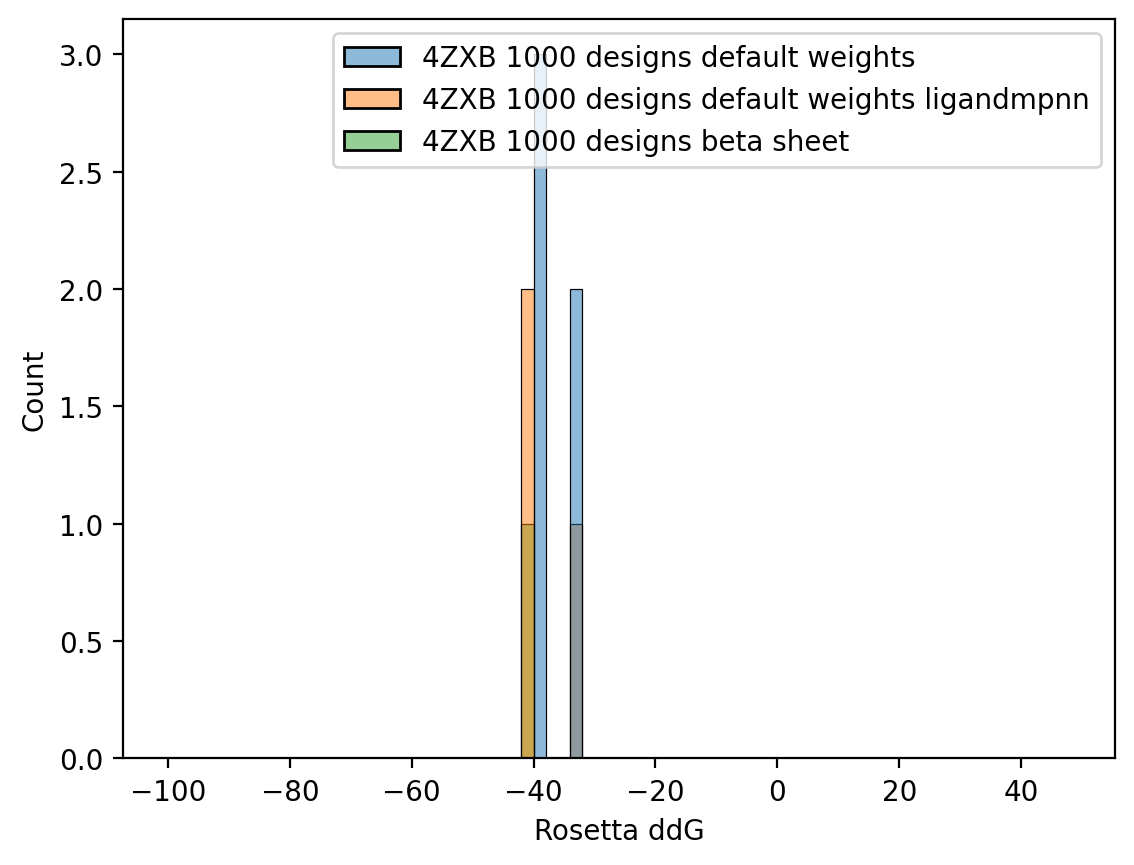

In [15]:
import numpy as np

hue = jobs[('Pool','name')].loc[rf_binder_designs.pool_id]
sns.histplot(rf_binder_designs, x='Rosetta ddG', hue=hue.values, bins=np.arange(-100, 50, 2));

### Paso 16: Diseños aceptados de binder (los "ganadores")

Filtra solo los diseños que pasaron TODOS los umbrales (AF2 + Rosetta). Estos son los candidatos que se seleccionarian para validacion experimental en laboratorio.

In [16]:
accepted_rf_binder_designs = rf_binder_designs[rf_binder_designs['accepted']]
accepted_rf_binder_designs

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,...,0.008814,2397.582566,0.517766,2397.582566,0.517766,-53204.939693,247.264672,-37802.189478,524.728685,-53729.668377
ovo_avz_0124_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,...,0.002133,1329.886461,0.221943,494.351643,0.082502,-29282.013327,1603.259674,-20382.537688,5073.431641,-34355.444969
ovo_avz_0299_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MSIEEIKKILEEIKKEAEAKNAKKVAEAAAKDPELAKKLAAELTAE...,...,0.013346,1431.141721,0.264025,1222.315483,0.225499,-31439.230457,1221.440562,-21455.968271,3326.778095,-34766.008552
ovo_avz_0481_cycle03,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MEAALKAAEEEKEFQKQVELAKLMIESYKKEGDEEQAEYWEKILEE...,...,0.004164,2322.248872,0.491070,2295.299667,0.485372,-62153.827602,169.365019,-47174.741642,462.410420,-62616.238021
ovo_avz_0732_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKEKKLKELEKQAKEVEEEGRKKVKEAEAKLKAGDKSEEVKEL...,...,0.026966,1342.739388,0.243623,1156.812464,0.209889,-18930.954449,6064.660410,-19659.415027,11991.801964,-30922.756413
ovo_bbc_0385_seq4,bbc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MSEVSEKTYEILKKYADSEESLLEGLKIALKEIEKERKYIDEDQLE...,...,0.050660,1593.451988,0.297579,690.407233,0.128934,-22964.616756,4640.841690,-19601.870041,8578.619584,-31543.236340
ovo_bbc_0388_seq1,bbc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MPFEERLKLAKETAKELKEEIEKEKDEEAKKKLQELLDILEKTLKE...,...,0.031025,1309.730849,0.305762,496.236589,0.115848,-21284.751527,2444.493582,-15861.385469,5027.644946,-26312.396472
ovo_bbc_0388_seq3,bbc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MPFEERLEIAKKTAEELKKEIEKEKDEEAKKQLEELLKLLEETLKK...,...,0.018297,1637.702058,0.382422,1636.850651,0.382223,-32095.566216,1328.163742,-23154.548375,3193.993927,-35289.560144
ovo_mmo_0951_cycle02,mmo,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MTIPEEILKQLEKLKKLAKESNVFDVEFKIVQNEDGSWSIEVVVKE...,...,0.027156,1385.199046,0.249139,673.281612,0.121095,-23669.266951,4127.009359,-20027.421342,8435.121421,-32104.388371


### Paso 17: Valores de Rosetta ddG de los diseños aceptados

Muestra los valores de ddG de los diseños "ganadores". Valores como -40 a -70 REU indican union predicha muy fuerte. Estos serian los candidatos prioritarios para sintesis y validacion experimental.

In [17]:
accepted_rf_binder_designs['Rosetta ddG']

id
ovo_avz_0030_cycle02   -38.108719
ovo_avz_0124_cycle04   -39.804649
ovo_avz_0299_cycle01   -33.983391
ovo_avz_0481_cycle03   -39.449741
ovo_avz_0732_cycle04   -33.147793
ovo_bbc_0385_seq4      -40.092587
ovo_bbc_0388_seq1      -32.078648
ovo_bbc_0388_seq3      -40.281807
ovo_mmo_0951_cycle02   -40.518124
Name: Rosetta ddG, dtype: float64

---
## SECCION D: Diversificacion por Difusion Parcial

### Que es la difusion parcial

La **difusion parcial** (partial diffusion) toma un diseño exitoso y le aplica "ruido" parcial con RFdiffusion para generar **variantes cercanas** en el espacio de diseño. Es como hacer pequeñas mutaciones 3D al backbone para explorar variantes similares que podrian tener propiedades mejoradas.

### El experimento: Pool qki

Se tomaron los **3 mejores diseños** de binder (por AF2 PAE, RMSD y ddG) y se generaron 50 backbones variantes por cada uno con 2 ciclos de FastRelax, totalizando ~450 diseños.

### Paso 18-20: Analisis del pool de diversificacion

In [18]:
rf_partial_jobs = jobs.loc[['qki']]
rf_partial_jobs

Pool  \
                                   name   
(Pool, id)                                
qki         Top designs diversification   

                                                         Job                \
                                          description status      duration   
(Pool, id)                                                                   
qki         Top 2 from each pool by PAE, RMSD and ddG   Done  118d:21h:34m   

                          Designs       Workflow                             \
                 created accepted total    input                       type   
(Pool, id)                                                                    
qki         4 months ago       37    37      NaN  RFdiffusion binder design   

                                                 RFdiffusion  ...  \
                                                     contigs  ...   
(Pool, id)                                                    ...   
qki         [62-62/0 B6-155, 71-71/0 B6-155, 70-70/0 B6-155]  ...   

                         BindCraft                               \
           number_of_final_designs time_limit_hours filter_type   
(Pool, id)                                                        
qki                            NaN              NaN         NaN   

                                                                 \
           design_protocol interface_protocol template_protocol   
(Pool, id)                                                        
qki                    NaN                NaN               NaN   

                                                         \
           prediction_protocol custom_advanced_settings   
(Pool, id)                                                
qki                        NaN                      NaN   

                                                
           custom_filter_settings num_replicas  
(Pool, id)                                      
qki                           NaN          NaN  

[1 rows x 50 columns]

In [19]:
rf_partial_jobs = jobs.loc[['qki']]

In [20]:
rf_partial_jobs[[
    ('Pool','name'), ('RFdiffusion', 'contigs'), ('RFdiffusion', 'hotspots'), ('RFdiffusion', 'num_designs'), 
    ('ProteinMPNN', 'num_sequences'), ('ProteinMPNN', 'fastrelax_cycles')
]]

Pool  \
                                   name   
(Pool, id)                                
qki         Top designs diversification   

                                                 RFdiffusion               \
                                                     contigs     hotspots   
(Pool, id)                                                                  
qki         [62-62/0 B6-155, 71-71/0 B6-155, 70-70/0 B6-155]  B64,B88,B96   

                         ProteinMPNN                   
           num_designs num_sequences fastrelax_cycles  
(Pool, id)                                             
qki               50.0           1.0              2.0

In [21]:
rf_partial_jobs[['Pool', 'Designs', 'Thresholds']].dropna(how='all', axis=1)

Pool  \
                                   name   
(Pool, id)                                
qki         Top designs diversification   

                                                       Designs        \
                                          description accepted total   
(Pool, id)                                                             
qki         Top 2 from each pool by PAE, RMSD and ddG       37    37   

           Thresholds                                                  \
             AF2 iPAE AF2 Target-aligned Binder RMSD AF2 Binder pLDDT   
(Pool, id)                                                              
qki          ≤ 10.000                        ≤ 2.000         ≥ 80.000   

                        
           Rosetta ddG  
(Pool, id)              
qki          ≤ -30.000

In [22]:
rf_partial_jobs[('RFdiffusion','contigs')].iloc[0]

['62-62/0 B6-155', '71-71/0 B6-155', '70-70/0 B6-155']

In [23]:
rf_partial_designs = designs[designs['pool_id'].isin(['qki'])]
rf_partial_designs.head()

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_qki_01_01_cycle01,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEERAERLADLMLRANELAESQESEEDREKLIALAEEILEDEEAL...,...,0.000204,3575.630396,0.777068,3573.380175,0.776579,-83149.918255,18.991748,-66534.429361,51.628696,-83201.546952
ovo_qki_01_11_cycle02,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,SEEEKLEEFWEVVQLWHEAALAAPTPEASQRIIDYLNELLLDLEKA...,...,NaN,1526.624412,0.350490,874.812494,0.200844,-43039.746728,35.366980,-27783.255916,145.986638,-43185.733366
ovo_qki_01_14_cycle01,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEIWEKFAEIALELNEEFEKSGDEEAMKIAEKILDEMLDNPEKI...,...,NaN,3128.260627,0.694402,3128.260627,0.694402,-65406.967614,29.286985,-49762.955262,104.353135,-65511.320748
ovo_qki_01_15_cycle02,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MEREKLLLLWESMELGQKVIEKTKDEELKKKVIEEVDKLIDDEELL...,...,0.008937,1424.381815,0.294227,1053.105138,0.217534,-30181.031052,1257.924646,-21542.964534,3272.441808,-33453.472860
ovo_qki_01_21_cycle03,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MELEGWENVMNALLELNKLAEKAKTEEEKKAYLEKGEEIIKNPEKY...,...,0.003364,1234.621555,0.270786,586.255949,0.128582,-25374.978251,960.625944,-15912.187385,2598.117097,-27973.095349


In [24]:
accepted_rf_partial_designs = rf_partial_designs[rf_partial_designs['accepted']]
accepted_rf_partial_designs['contig_index'].value_counts()

contig_index
0    17
1    13
2     7
Name: count, dtype: int64

### Resumen del experimento de binder design y diversificacion (segun el paper)

**Binder design de novo:** El workflow se aplico para diseñar una mini-proteina binder de **50 a 100 residuos** contra el receptor de insulina (PDB 4ZXB, cadena E, residuos 6-155), apuntando a los residuos hotspot **64, 88 y 96**. En total se generaron: **1000 backbones x 3 pasos de ProteinMPNN FastRelax** (+ 1 diseño inicial de ProteinMPNN) = **4000 secuencias generadas**, que se filtraron con AlphaFold2 (iPAE < 10, pLDDT > 80, Target-aligned Binder RMSD < 2 A) y Rosetta (ddG < -30).

**Resultado con pesos default:** **5 diseños aceptados** de 4000. Con pesos de RFdiffusion para laminas beta (*beta sheet*), se obtuvo **1 diseño aceptado** con un 20% de la estructura formando laminas beta.

**Diversificacion por difusion parcial:** Se aplico difusion parcial (50 backbones x 2 pasos de FastRelax) sobre los **3 diseños mas confiables** segun AF2. De 450 diseños generados, **37 fueron aceptados** por los umbrales default de AlphaFold2 y Rosetta, correspondiendo a una **tasa de exito in silico del 8.2%**, comparada con el **0.075%** de los diseños de novo originales (6/8000). Esto demuestra que la difusion parcial permite explorar eficientemente regiones cercanas del espacio estructural.

### Resultados de diversificacion

**Resultado clave del paper:** De 450 diseños por difusion parcial, **37 fueron aceptados** (8.2% de tasa de exito). Comparado con el diseño de novo original donde solo 6 de 8000 fueron aceptados (0.075%), la difusion parcial tiene una **tasa de exito ~100x mayor**. Esto demuestra que explorar el espacio cercano a un buen diseño es mucho mas eficiente que buscar desde cero.

El `contig_index` indica de cual de los 3 diseños originales proviene cada variante aceptada. Esto permite ver si algunos diseños "semilla" producen mas variantes exitosas que otros.

In [25]:
bindcraft_jobs = jobs.loc[['rsj']]
bindcraft_jobs[['Pool','Designs','BindCraft']]

Pool  \
                              name   
(Pool, id)                           
rsj         4ZXB BindCraft default   

                                                               Designs        \
                                                  description accepted total   
(Pool, id)                                                                     
rsj         Insulin receptor miniprotein binders hotspot E...       13    13   

               BindCraft                                                     \
           target_chains binder_length     hotspots number_of_final_designs   
(Pool, id)                                                                    
rsj                    E        50,100  E64,E88,E96                    20.0   

                                                                            \
           time_limit_hours filter_type design_protocol interface_protocol   
(Pool, id)                                                                   
rsj                     6.0     Default         Default         AlphaFold2   

                                                                           \
           template_protocol prediction_protocol custom_advanced_settings   
(Pool, id)                                                                  
rsj                  Default             Default                       {}   

                                                
           custom_filter_settings num_replicas  
(Pool, id)                                      
rsj                            {}          1.0

In [26]:
# from ovo import db

# for j in db.DesignJob.select():
#     pool = db.Pool.get(design_job_id=j.id)
#     print(pool.name, j.job_id)

---
## SECCION E: Binder Design con BindCraft

### Que es BindCraft

**BindCraft** es un metodo alternativo a RFdiffusion para diseñar binders. Usa **retropropagacion a traves de AlphaFold2** para optimizar directamente la secuencia y estructura del binder. Es mas lento pero puede producir diseños de mayor calidad porque optimiza directamente la confianza de AF2.

### El experimento: Pool rsj

Se diseñaron binders contra el mismo target (receptor de insulina 4ZXB, hotspots 64, 88, 96) pero usando BindCraft en lugar de RFdiffusion. Se corrio durante 6 horas en 1 GPU A10G.

### Paso 21: Parametros y resultados de BindCraft

**Resultado:** BindCraft produjo **13 diseños aceptados** y 95 rechazados por filtros AF2, sin trayectorias rechazadas durante el protocolo de diseño. Esto sugiere que AF2 tiene preferencia por el epitopo seleccionado del target.

### Resumen del experimento BindCraft (segun el paper)

Se diseño una mini-proteina binder de **50 a 100 residuos** contra el receptor de insulina (PDB 4ZXB, cadena E, residuos 6-155), apuntando a los residuos hotspot **64, 88 y 96**, usando BindCraft (optimizacion por retropropagacion a traves de AlphaFold2).

La ejecucion durante **6 horas en 1 GPU A10G** produjo:
- **13 diseños aceptados** por los filtros default de AlphaFold2 y Rosetta
- **95 diseños rechazados** por los filtros de AlphaFold2
- **Ninguna trayectoria rechazada** durante el protocolo de diseño

La ausencia de trayectorias rechazadas podria atribuirse a la preferencia de AlphaFold2 por el epitopo seleccionado del target, lo que sugiere que este sitio de union es favorable para el diseño computacional.
